## 1. Data Loading and Initial Inspection

In [ ]:
# 1. Data loading and initial inspection
import pandas as pd
import numpy as np

df = pd.read_csv("sample.csv")

## 2. Data Cleaning and Transformation

In [ ]:
  # 2. Data cleaning and transformation
df.drop(['key', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'time_signature'], axis=1, inplace=True)

      # Note: The cleaned data (before transformations) is then exported onto another file (processed_sample.csv).

    # Handle missing values
    #  - Drop rows where key info is missing
df = df.dropna(subset=["track_name", "artists"])

    #  - Fill missing numeric values
df["popularity"] = df["popularity"].fillna(df["popularity"].median())

    # Type conversion
df["duration_ms"] = pd.to_numeric(df["duration_ms"], errors="coerce")
df["popularity"] = pd.to_numeric(df["popularity"], errors="coerce")
    # (No date column)

    # Creating a new column
df["popularity_level"] = np.where(
    df["popularity"] > 70, "High",
    np.where(df["popularity"] > 40, "Medium", "Low")
)

df["duration_sec"] = df["duration_ms"] // 1000
df["minutes"] = df["duration_sec"] // 60
df["seconds"] = df["duration_sec"] % 60

df["duration_mmss"] = (df["minutes"].astype(str) + ":" + df["seconds"].astype(str).str.zfill(2) )

    # Grouping
track_genre_stats = df.groupby("track_genre")["popularity"].agg(["count", "mean"])
genre_audio = df.groupby("track_genre")[["energy", "danceability"]].agg(["mean", "std"])

    # Reshaping - Pivot table   (concat/merge not required [one dataset])
pivot = df.pivot_table(
    index="track_genre",
    values="popularity",
    aggfunc="mean"
)

    # - melt
melted = pd.melt(df,
                 id_vars=["track_name", "artists"],
                 value_vars=["danceability", "energy", "valence"],
                 var_name="feature",
                 value_name="score")


    # Outputting the changes onto a seperate file.
# df.to_csv("processed_sample.csv", index=False)

df

Columns unrelated to our analysis were removed. No missing values needed to be removed. Sample was too large initally so the first 500 entries were used.

## 3. Descriptive Statistics and Simple EDA

In [ ]:
# 3. Descriptive statistics and simple EDA
numeric_cols = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "liveness",
    "tempo",
    "duration_ms",
    "valence"
]

df[numeric_cols].describe()

df[numeric_cols].agg(["mean","median", "min", "max", "std"])

The average popularity of the tracks was 31.8, so most tracks in the dataset were obscure. Danceability and energy were at 0.57 and 0.65, both moderate values. Tempo ranges from 48 to 211 bpm, showing the dataset has a wide variety of genres. Duration varies from 34 seconds to over 11 minutes, with the average track being about 3 minutes and 30 seconds.

In [ ]:
genre_stats = df.groupby("track_genre")["popularity"].agg(["mean", "median", "min", "max", "std", "count"])
genre_stats.head()

Grouping by genre reveals several differences. Emo had the highest average popularity at 73.3, followed by K-Pop and pop at 62.0 and 60.4 respectively. Genres like alt-rock, jazz, and Iranian ranked the lowest in popularity. The standard deviation was high in many genres, showing great variety in popularity in tracks of the same genre. For example, the standard deviation of pop was 34.8.

In [ ]:
corr_matrix = df[numeric_cols].corr()
corr_matrix

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Spotify Audio Features")
plt.show()

The strongest correlation was between energy and loudness at 0.73, showing louder tracks tend to feel more energetic. Danceability and valence also moderately correlate, suggesting more positive songs are most danceable. Most notably, popularity does not show much correlation to any audio feature. This indicates a tracks success depends on others factors outside of audio traits.

## 4. Visualizations and Feature Exploration

/tmp/ipykernel_23523/1826730014.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tempo_trend = df.groupby("energy_bin")["popularity"].mean()


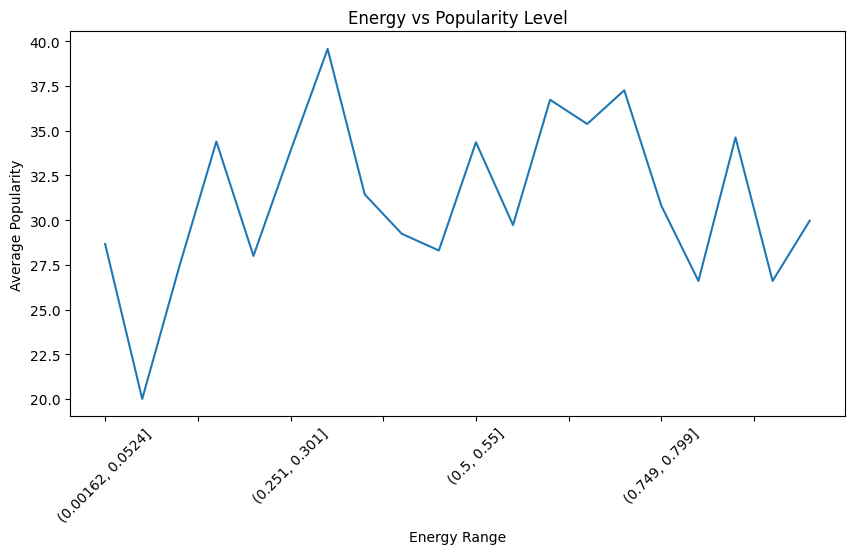

/tmp/ipykernel_23523/1826730014.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_popularities, x="popularity", y="track_genre", ax=ax, palette="viridis")


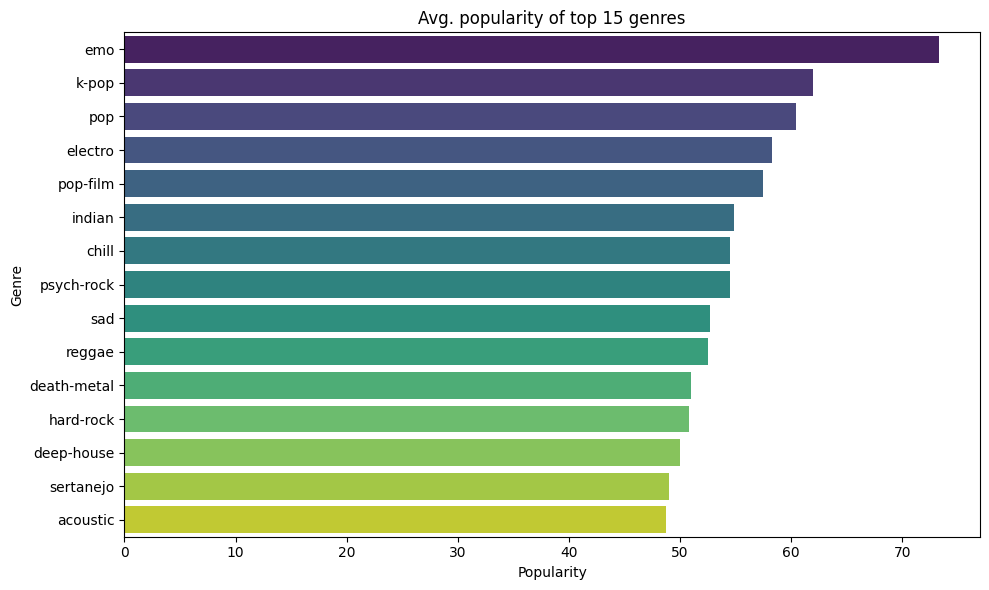

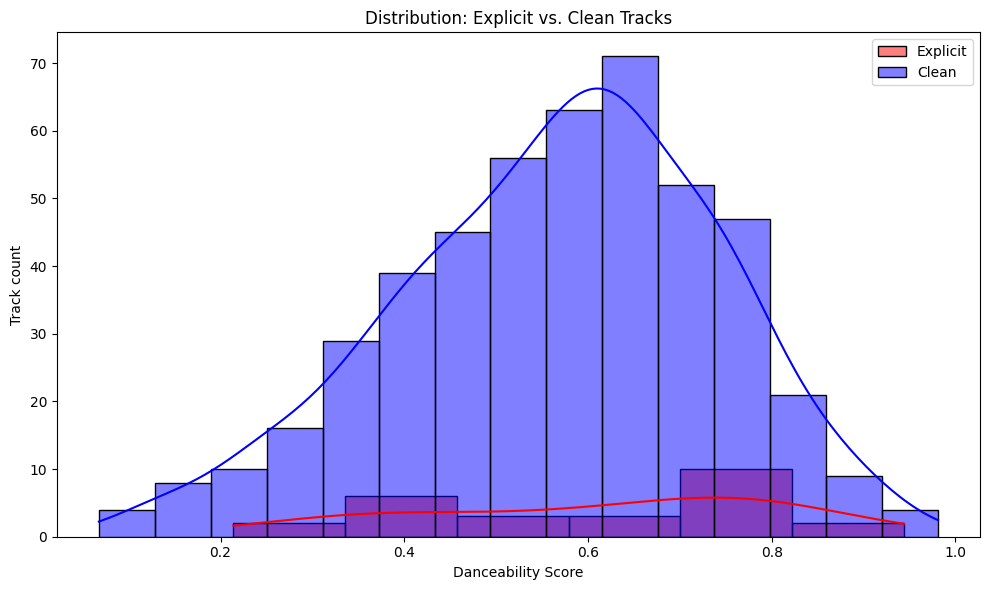

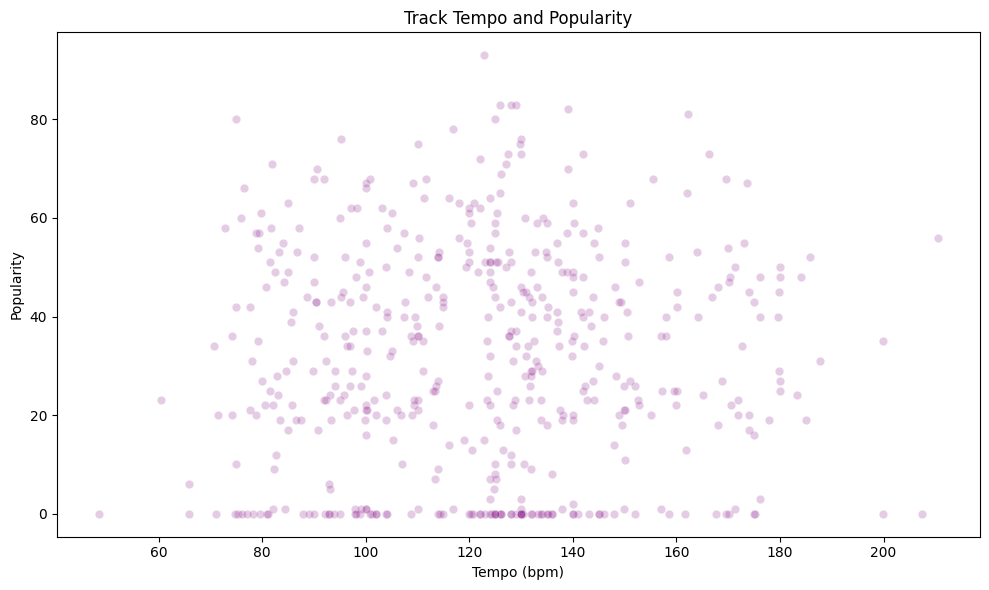

In [32]:
# 4. Visualizations and feature exploration

# energy vs popularity
df["energy_bin"] = pd.cut(df["energy"], bins=20)

tempo_trend = df.groupby("energy_bin")["popularity"].mean()

plt.figure(figsize=(10,5))
tempo_trend.plot()

plt.title("Energy vs Popularity Level")
plt.xlabel("Energy Range")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45)
plt.show()

# question 1: Do certain genres tend to be more popular?
# use processed data
df = pd.read_csv("/content/processed_sample.csv")
# make output dir for figures
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("figures", exist_ok=True)

# get df of top 15 genres by avg popularities
genre_popularities = df.groupby("track_genre")["popularity"].mean().reset_index().sort_values(by="popularity", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(data=genre_popularities, x="popularity", y="track_genre", ax=ax, palette="viridis")
ax.set_title("Avg. popularity of top 15 genres")
ax.set_xlabel("Popularity")
ax.set_ylabel("Genre")
plt.tight_layout()
plt.savefig("figures/genre_popularities.png", dpi=300)
plt.show()


# question 2: what is the danceability of explicit songs compared to non-explicit songs?
fig, ax = plt.subplots(figsize=(10, 6))

# distributions for explicit (True) and non-explicit (False)
sns.histplot(data=df[df['explicit'] == True], x="danceability", color="red", label="Explicit", kde=True, ax=ax, alpha=0.5)
sns.histplot(data=df[df['explicit'] == False], x="danceability", color="blue", label="Clean", kde=True, ax=ax, alpha=0.5)

ax.set_title("Distribution: Explicit vs. Clean Tracks")
ax.set_xlabel("Danceability Score")
ax.set_ylabel("Track count")
ax.legend()
fig.tight_layout()

fig.savefig("figures/explicit_dance_hist.png", dpi=300)
plt.show()


# question 3: do high tempo songs perform better than low tempo songs?
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x="tempo", y="popularity", ax=ax, alpha=0.2, color="purple")

ax.set_title("Track Tempo and Popularity")
ax.set_xlabel("Tempo (bpm)")
ax.set_ylabel("Popularity")

fig.tight_layout()
fig.savefig("figures/tempo_popularity_scat.png", dpi=300)

The line plot shows the relationship between energy and popularity, showing it's highest average popularity to be around the 0.251, 0.301 energy range. The bar chart confirms emo, K-Pop, and pop lead in popularity. The histogram comparing explicit and non-explicit tracks show explicit tracks are slighty more danceable, 0.61 vs 0.57. They also have higher average popularity, 45.2 vs 31.1, despite making up only 26 of the 500 tracks. The scatter plot of shows that a significant number of popular tracks fell in the 100-150 bpm range. This suggest more moderate tempos tend to be more popular

## 5. Summary and Key Findings

This data analysis examined relationships between song popularity and engagement. Categories that were studied as EDA research questions include genre, lyrical explicitness, and tempo.

Analysis of average popularity showed that certain genres (such as emo, k-pop, and pop) consistently achieved higher average popularity scores, which can reflect trends and mainstream audience appeal. This was shown using a horizontal bar graph.

To compare the danceability between explicit and non-explicit tracks, a histogram was used. This showed that explicit songs had on average a higher danceability score than non-explicit songs, despite the amount of non-explicit tracks being significantly greater than explicit tracks. This showed that explicit tracks in this dataset tend to have more rhythm.

Comparisons between high and low tempo songs were determined using a scatterplot. This showed that on average, songs between the range of 100-160 bpm had a higher popularity count than 0-60 bpm tracks and 120-200 bpm tracks. This shows that songs with a moderate tempo tend to be far more popular due to a balance between energy and accessibility.
